### Load the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv(r'D:\CUSTOMER-CHURN\Dataset\churn_dataset_cleaned.csv')

# 2. Drop customerID and TotalCharges (Multicollinearity fix)
cols_to_drop = [col for col in ['customerID', 'TotalCharges'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 3. Encode Target
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

# 4. Separate X and Y
Y = df['Churn'] 
X = df.drop(columns=['Churn'])

# 5. Dummy Variables (Turn text into 0s and 1s)
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 6. Train/Test Split (Stratified to keep the realistic Churn ratio)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

print("✅ Step 1 Complete: Data is loaded, cleaned, and split!")
print(f"Current Training Features: {X_train.shape[1]}")

✅ Step 1 Complete: Data is loaded, cleaned, and split!
Current Training Features: 22


Calculating Mutual Information Scores... Please wait.


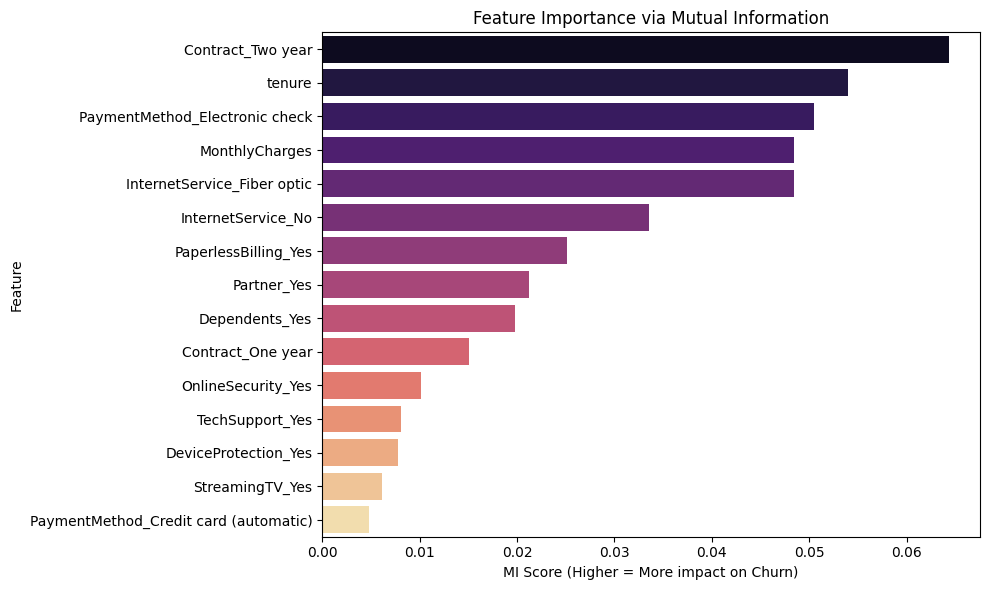

,Feature,MI_Score
0,Contract_Two year,0.064287
1,tenure,0.053970
2,PaymentMethod_Electronic check,0.050485
3,MonthlyCharges,0.048427
4,InternetService_Fiber optic,0.048392
5,InternetService_No,0.033566
6,PaperlessBilling_Yes,0.025146
7,Partner_Yes,0.021226
8,Dependents_Yes,0.019845
9,Contract_One year,0.015124


In [3]:
# ==========================================
# STEP 2: MUTUAL INFORMATION (FEATURE SELECTION)
# ==========================================

from sklearn.feature_selection import mutual_info_classif

print("Calculating Mutual Information Scores... Please wait.")

# 1. Run the statistical test
mi_scores = mutual_info_classif(X_train, Y_train, random_state=42)

# 2. Create a clean DataFrame to view the results
mi_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MI_Score': mi_scores
})

# 3. Sort from most important to least important
mi_df = mi_df.sort_values(by='MI_Score', ascending=False).reset_index(drop=True)

# 4. Plot the top 15 features
plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_df.head(15), palette='magma')
plt.title('Feature Importance via Mutual Information')
plt.xlabel('MI Score (Higher = More impact on Churn)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

display(mi_df.head(10))

In [4]:
# ==========================================
# STEP 1: LOAD, FILTER, ENCODE & SPLIT
# ==========================================
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the dataset
df = pd.read_csv(r'D:\CUSTOMER-CHURN\Dataset\churn_dataset_cleaned.csv')

# 2. Select ONLY our 8 Master Features + Target
top_features = [
    'Contract', 'tenure', 'PaymentMethod', 'MonthlyCharges', 
    'InternetService', 'PaperlessBilling', 'Partner', 'Dependents', 'Churn'
]

# Create a fresh, lightweight dataframe
df_light = df[top_features].copy()

# 3. Encode Target Variable (Churn)
df_light['Churn'] = df_light['Churn'].replace({'Yes': 1, 'No': 0})

# 4. Separate Features (X) and Target (Y)
Y = df_light['Churn'] 
X = df_light.drop(columns=['Churn'])

# 5. Categorical Encoding (Dummy Variables)
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 6. Train/Test Split (75% Train, 25% Test, Stratified to keep realistic churn ratios)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

print("✅ Step 1 Complete: Data Filtered, Encoded, and Split (75/25)!")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

✅ Step 1 Complete: Data Filtered, Encoded, and Split (75/25)!
Shape of X_train: (5282, 12)
Shape of X_test: (1761, 12)


In [5]:
# ==========================================
# STEP 2: TARGETED SCALING (LIGHTWEIGHT)
# ==========================================
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scale = StandardScaler()

# 2. Make safe copies of our split data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 3. Define ONLY the continuous columns
num_cols = ['tenure', 'MonthlyCharges']

# 4. Fit and Transform the training data
X_train_scaled[num_cols] = scale.fit_transform(X_train[num_cols])

# 5. Transform the test data (Never fit on test data!)
X_test_scaled[num_cols] = scale.transform(X_test[num_cols])

print("✅ Step 2 Complete: Continuous Variables Scaled!")
display(X_train_scaled.head())

✅ Step 2 Complete: Continuous Variables Scaled!


,tenure,MonthlyCharges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,PaperlessBilling_Yes,Partner_Yes,Dependents_Yes
6661,1.609608,-0.371461,0,1,1,0,0,0,0,0,1,1
4811,-1.151780,-0.625032,0,0,0,0,1,0,0,1,0,0
2193,0.959870,-1.447065,1,0,0,0,1,0,1,1,0,1
1904,0.959870,0.980917,0,0,0,1,0,1,0,1,0,0
6667,-0.948737,0.487034,0,0,0,1,0,1,0,1,0,0


In [6]:
# ==========================================
# STEP 3: HANDLING IMBALANCE (SMOTE)
# ==========================================
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE with a random state
smote = SMOTE(random_state=42)

# 2. Fit and apply SMOTE strictly to the scaled training data
X_train_bal, Y_train_bal = smote.fit_resample(X_train_scaled, Y_train)

# 3. Verify the balancing worked
print("✅ Step 3 Complete: Lightweight Training Data Balanced!")
print("\n--- Before SMOTE (Imbalanced) ---")
print(Y_train.value_counts())

print("\n--- After SMOTE (Perfectly Balanced) ---")
print(Y_train_bal.value_counts())

✅ Step 3 Complete: Lightweight Training Data Balanced!

--- Before SMOTE (Imbalanced) ---
Churn
0    3880
1    1402
Name: count, dtype: int64

--- After SMOTE (Perfectly Balanced) ---
Churn
0    3880
1    3880
Name: count, dtype: int64


In [7]:
# ==========================================
# STEP 4: MODEL EVALUATION & BENCHMARKING
# ==========================================
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Initialize classification models for benchmarking
# Setting random_state where applicable ensures reproducibility across pipeline runs.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

# List to store the evaluation metrics for each model
evaluation_metrics = []

print("Initiating model training and evaluation sequence. Please wait...\n")

# 2. Iterate through models, train on balanced data, and evaluate on unseen test data
for model_name, model in models.items():
    
    # Fit the model using the SMOTE-balanced training set
    model.fit(X_train_bal, Y_train_bal)
    
    # Generate predictions on the scaled, imbalanced test set
    y_pred = model.predict(X_test_scaled)
    
    # Compute standard classification metrics
    accuracy = accuracy_score(Y_test, y_pred)
    precision = precision_score(Y_test, y_pred)
    recall = recall_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred)
    
    # Append results
    evaluation_metrics.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# 3. Compile the results into a DataFrame and sort by F1-Score
benchmark_results = pd.DataFrame(evaluation_metrics)
benchmark_results = benchmark_results.sort_values(by='F1-Score', ascending=False)
benchmark_results.reset_index(drop=True, inplace=True)

# 4. Display the final benchmarking report
print("--- Model Evaluation Benchmark (8-Feature Dataset) ---")
display(benchmark_results)

Initiating model training and evaluation sequence. Please wait...

--- Model Evaluation Benchmark (8-Feature Dataset) ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Gradient Boosting,0.747303,0.515493,0.783726,0.621920
1,Logistic Regression,0.735945,0.501366,0.785867,0.612177
2,Naive Bayes,0.708120,0.470440,0.800857,0.592710
3,K-Nearest Neighbors,0.730267,0.494186,0.728051,0.588745
4,Random Forest,0.750142,0.525234,0.601713,0.560878
5,Decision Tree,0.696195,0.440767,0.541756,0.486071


In [8]:
# ==========================================
# STEP 5: FINAL MODEL EXPORT & ARTIFACTS
# ==========================================
import os
import pickle
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

print("Training final production models for deployment...")

# 1. Train Champion 1: Gradient Boosting (with SMOTE for high recall)
gbdt_prod = GradientBoostingClassifier(random_state=42)
gbdt_prod.fit(X_train_bal, Y_train_bal)

# 2. Train Champion 2: Logistic Regression (with SMOTE)
lr_prod = LogisticRegression(max_iter=1000, random_state=42)
lr_prod.fit(X_train_bal, Y_train_bal)

# 3. Train the "Pure" Logistic Regression (NO SMOTE - for realistic UI probabilities)
pure_lr_prod = LogisticRegression(max_iter=1000, random_state=42)
# Notice we train this on X_train_scaled, NOT the balanced SMOTE data
pure_lr_prod.fit(X_train_scaled, Y_train) 

# 4. Export the models, scaler, and column list
save_dir = r"D:\Customer-Churn\Models"
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'churn_model_light_gbdt.pkl'), 'wb') as f:
    pickle.dump(gbdt_prod, f)

with open(os.path.join(save_dir, 'churn_model_light_lr.pkl'), 'wb') as f:
    pickle.dump(lr_prod, f)

with open(os.path.join(save_dir, 'churn_model_light_pure_lr.pkl'), 'wb') as f:
    pickle.dump(pure_lr_prod, f)

with open(os.path.join(save_dir, 'scaler_light.pkl'), 'wb') as f:
    pickle.dump(scale, f) # Saving the scaler from Step 2

with open(os.path.join(save_dir, 'model_columns_light.pkl'), 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f) # Saving the exact 8-feature layout

print(f"✅ Production models and artifacts successfully exported to {save_dir}!")

Training final production models for deployment...
✅ Production models and artifacts successfully exported to D:\Customer-Churn\Models!


In [9]:
# ==========================================
# STEP 6: HYPERPARAMETER TUNING (GBDT)
# ==========================================
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, recall_score
import pickle
import os

print("Starting Grid Search for Gradient Boosting...")
print("Testing parameter combinations... this might take 1-3 minutes depending on your CPU.")

# 1. Define the parameter grid (The "levers" we are pulling)
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'learning_rate': [0.01, 0.05, 0.1],  # How fast the model learns
    'max_depth': [3, 4, 5]               # How deep each tree can grow
}

# 2. Initialize the base model
gbdt_base = GradientBoostingClassifier(random_state=42)

# 3. Setup GridSearchCV
# We use scoring='f1' because finding the balance of catching churners is our business goal
grid_search = GridSearchCV(
    estimator=gbdt_base, 
    param_grid=param_grid, 
    scoring='f1',      
    cv=5,              # 5-fold cross-validation for stability
    n_jobs=-1,         # Uses all your CPU cores to run it as fast as possible
    verbose=1
)

# 4. Fit the Grid Search strictly on the balanced lightweight training data
grid_search.fit(X_train_bal, Y_train_bal)

# 5. Extract the absolute best model
gbdt_tuned = grid_search.best_estimator_

print("\n✅ Tuning Complete!")
print(f"Best Parameters Found: {grid_search.best_params_}")

# 6. Evaluate the new champion on the unseen test data
y_pred_tuned = gbdt_tuned.predict(X_test_scaled)
new_f1 = f1_score(Y_test, y_pred_tuned)
new_recall = recall_score(Y_test, y_pred_tuned)

print(f"\n🏆 Tuned Model Test Set F1-Score: {new_f1:.4f}")
print(f"🏆 Tuned Model Test Set Recall: {new_recall:.4f}")

# 7. Save the new tuned model safely alongside the old ones
save_dir = r"D:\Customer-Churn\Models"
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'churn_model_light_gbdt_TUNED.pkl'), 'wb') as f:
    pickle.dump(gbdt_tuned, f)
    
print(f"\n💾 Tuned model successfully saved to {save_dir} as 'churn_model_light_gbdt_TUNED.pkl'")

Starting Grid Search for Gradient Boosting...
Testing parameter combinations... this might take 1-3 minutes depending on your CPU.
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Tuning Complete!
Best Parameters Found: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

🏆 Tuned Model Test Set F1-Score: 0.6186
🏆 Tuned Model Test Set Recall: 0.7345

💾 Tuned model successfully saved to D:\Customer-Churn\Models as 'churn_model_light_gbdt_TUNED.pkl'
